## Chi $^2$ Verteilung

#### Sampling


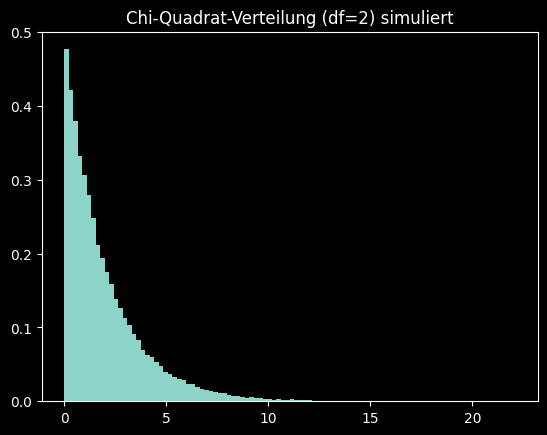

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 100000
df = 2  # Freiheitsgrade

# k Standardnormalverteilungen -> quadrieren -> summieren
z = np.random.normal(0, 1, (n_samples, df))
chi2_samples = np.sum(z**2, axis=1)

plt.hist(chi2_samples, bins=100, density=True)
plt.title(f"Chi-Quadrat-Verteilung (df={df}) simuliert")
plt.show()

#### Exact

In [1]:
from scipy.stats import chi2
tau_h4 = chi2.ppf(0.95, df=2)
tau_h4

np.float64(5.991464547107979)

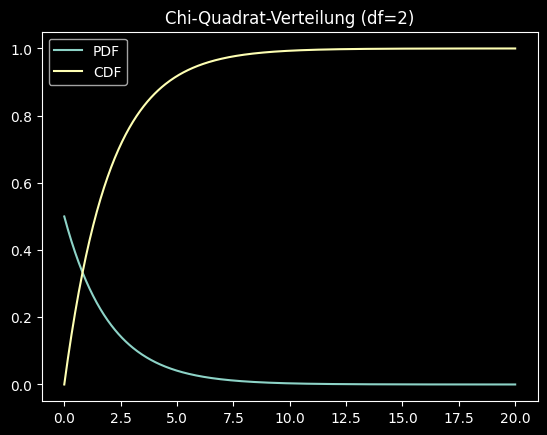

In [2]:
from scipy.stats import chi2

df = 2
x = np.linspace(0, 20, 500)

pdf = chi2.pdf(x, df)
cdf = chi2.cdf(x, df)

plt.plot(x, pdf, label="PDF")
plt.plot(x, cdf, label="CDF")
plt.legend()
plt.title(f"Chi-Quadrat-Verteilung (df={df})")
plt.show()

#### Goodness-of-fit Test

In [12]:
observed = np.array([18, 16, 14, 10, 12, 20])
expected = np.ones(6) * np.mean(observed)

chi_stat = np.sum((observed - expected)**2 / expected)
chi_stat

np.float64(4.666666666666667)

In [13]:
df = len(observed) - 1

p_value = 1 - chi2.cdf(chi_stat, df)
p_value

np.float64(0.4578982272454013)

In [14]:
print("Chi² Statistik:", chi_stat)
print("p-Wert:", p_value)

Chi² Statistik: 4.666666666666667
p-Wert: 0.4578982272454013


In [15]:
import pandas as pd
from scipy.stats import chi2_contingency

data = np.array([
    [30, 10],  # Raucher: krank / gesund
    [20, 40]   # Nichtraucher: krank / gesund
])

chi2_stat, p, dof, expected = chi2_contingency(data)

print("Chi²:", chi2_stat)
print("p-Wert:", p)
print("Freiheitsgrade:", dof)
print("Erwartete Werte:\n", expected)

Chi²: 15.041666666666666
p-Wert: 0.00010516355403363098
Freiheitsgrade: 1
Erwartete Werte:
 [[20. 20.]
 [30. 30.]]


### Mahalanobis Distance

In [13]:
import numpy as np
from scipy.stats import chi2

np.random.seed(0)

# Dimension der Messung
k = 2

# Beispiel: Innovation (Messfehler)
y = np.array([0.2, -0.7])

# Kovarianz der Innovation (S)
S = np.array([
    [2.0, 0.3],
    [0.3, 1.0]
])

In [14]:
S_inv = np.linalg.inv(S)

d2 = y.T @ S_inv @ y
d2

np.float64(0.5780104712041884)

In [15]:
def nis_evidence_split(nis, k):
    cdf = chi2.cdf(nis, df=k)

    if cdf > 0.5:
        # rechte Seite (zu groß)
        over = 2 * (cdf - 0.5)
        under = 0
    else:
        # linke Seite (zu klein)
        under = 2 * (0.5 - cdf)
        over = 0

    typical = 1 - (over + under)

    return typical, over, under

In [32]:
nis_evidence_split(1.386294361119891, k)

(np.float64(1.0), 0, np.float64(0.0))

In [31]:
chi2.ppf(0.5, 2)

np.float64(1.386294361119891)

In [44]:
def nis_typicality_mean_based(nis, k):
    # normierte Abweichung vom Erwartungswert
    z = abs(nis - k) / np.sqrt(2 * k)

    # Mapping in [0,1]
    return (np.exp(-z))

def nis_evidence_ll(nis, k):
    # χ² pdf (Likelihood)
    from scipy.stats import chi2

    likelihood = chi2.pdf(nis, df=k)
    max_likelihood = chi2.pdf(k-2 if k > 2 else k, df=k)

    return likelihood / max_likelihood

print(nis_typicality_mean_based(5, 2))
print(nis_typicality_mean_based(1.5, 2))

print(nis_evidence_ll(2.5, 2))
print(nis_evidence_ll(1.5, 2))
print(nis_evidence_ll(1., 2))

0.22313016014842982
0.7788007830714049
0.778800783071405
1.2840254166877416
1.648721270700128


In [17]:
p_value = 1 - chi2.cdf(d2, df=k)

print("Mahalanobis-Distanz²:", d2)
print("p-Wert (χ²):", p_value)

Mahalanobis-Distanz²: 0.5780104712041884
p-Wert (χ²): 0.7490082838830638


In [22]:
alpha = 0.05
threshold = chi2.ppf(1 - alpha, df=k)

print("Threshold:", threshold)

if d2 > threshold:
    print("❌ Messung wird verworfen (Ausreißer)")
else:
    print("✅ Messung akzeptiert")

Threshold: 5.991464547107979
✅ Messung akzeptiert


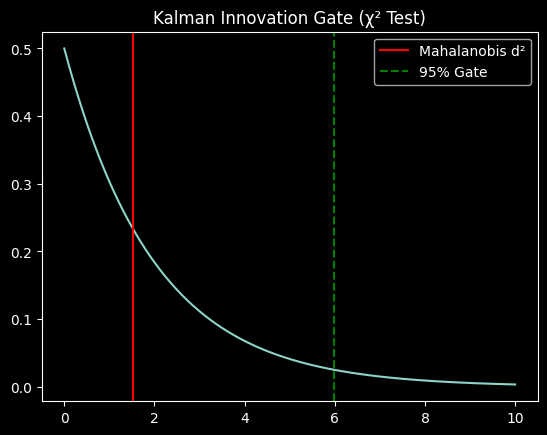

In [7]:
import matplotlib.pyplot as plt

df = 2
x = np.linspace(0, 10, 500)

plt.plot(x, chi2.pdf(x, df))

plt.axvline(d2, color='red', label='Mahalanobis d²')

plt.axvline(chi2.ppf(0.95, df), color='green', linestyle='--', label='95% Gate')

plt.title("Kalman Innovation Gate (χ² Test)")
plt.legend()
plt.show()

### NIS Test

In [24]:
import numpy as np
from scipy.stats import chi2

def compute_nis(y, S):
    S_inv = np.linalg.inv(S)
    nis = y.T @ S_inv @ y
    return nis

In [26]:
def nis_test(nis_values, k, alpha=0.05):
    N = len(nis_values)
    
    # Erwartungswert der Summe
    nis_sum = np.sum(nis_values)
    
    # Chi² Grenzen für Summe
    lower = chi2.ppf(alpha/2, df=N*k)
    upper = chi2.ppf(1 - alpha/2, df=N*k)
    
    print("NIS Sum:", nis_sum)
    print("Erwartungsintervall:", (lower, upper))
    
    if nis_sum < lower:
        print("⚠️ Filter overconfident (Unsicherheit zu klein)")
    elif nis_sum > upper:
        print("⚠️ Filter underconfident oder Modell falsch")
    else:
        print("✅ Konsistent")

def nis_to_evidence(nis, k):
    p = 1 - chi2.cdf(nis, df=k)
    
    # Mapping
    belief_evidence = p
    disbelief_evidence = 1 - p
    
    return belief_evidence, disbelief_evidence

def accumulate_evidence(nis_values, k):
    b = 0.0  # belief evidence
    d = 0.0  # disbelief evidence
    
    for nis in nis_values:
        be, de = nis_to_evidence(nis, k)
        b += be
        d += de
    
    return b, d

def evidence_to_opinion(b, d, W=2.0, a=0.5):
    total = b + d
    
    belief = b / (total + W)
    disbelief = d / (total + W)
    uncertainty = W / (total + W)
    
    return belief, disbelief, uncertainty, a

def weighted_nis_evidence(nis, k):
    p = 1 - chi2.cdf(nis, df=k)
    
    # Gewichtung über Überraschung (Information)
    weight = -np.log(max(p, 1e-10))
    
    belief = p * weight
    disbelief = (1 - p) * weight
    
    return belief, disbelief



In [27]:
nis_values = [...]

b, d = 0.0, 0.0

for nis in nis_values:
    be, de = weighted_nis_evidence(nis, k=2)
    b += be
    d += de

belief, disbelief, uncertainty, base = evidence_to_opinion(b, d)

print("Opinion:")
print("belief:", belief)
print("disbelief:", disbelief)
print("uncertainty:", uncertainty)

TypeError: unsupported operand type(s) for -: 'ellipsis' and 'int'

### KS-Test und KDE Ansatz

In [5]:
import numpy as np
from scipy.stats import chisquare

data = np.random.randint(0, 5, size=1000)

counts = np.bincount(data)
expected = np.ones_like(counts) * len(data)/len(counts)

chisquare(counts, expected)

Power_divergenceResult(statistic=np.float64(3.0), pvalue=np.float64(0.5578254003710748))

In [3]:
from scipy.stats import kstest
import numpy as np

samples = np.random.rand(1000)

kstest(samples, 'uniform')

KstestResult(statistic=np.float64(0.019509965072200347), pvalue=np.float64(0.8336958825258878), statistic_location=np.float64(0.14849003492779966), statistic_sign=np.int8(1))

In [4]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(samples)

u_grid = np.linspace(0,1,200)
p = kde(u_grid)

D_KL = np.trapz(p * np.log(p + 1e-12), u_grid)

AttributeError: module 'numpy' has no attribute 'trapz'